# 2nd Hidden Layer — Evaluate Little-Perturbation Checkpoints

In the 2nd-layer perturbation sweeps, models trained with a *little*
perturbation tend to score better at their matched evaluation level. This
notebook isolates that effect: for each perturbation type it loads a **single
checkpoint trained at a small perturbation level** and evaluates that one model
across the **entire** perturbation sweep (eval-on-checkpoint), rather than
training a fresh model per level.

Each perturbation is evaluated twice — once for the **no-delay** model and once
for the **delay** model — using the same checkpoint level:

- **Jitter** — per-spike Gaussian jitter; default checkpoint `sigma = 5`.
- **Shift** — per-neuron Gaussian shift; default checkpoint `sigma = 5`.
- **Deletion** — per-spike deletion; default checkpoint `p_d = 0.2`.

Evaluations cover the **whole / part / norm** SHD variants. Per-section results
are written to `log_eval_on_perturbatedModel/`, and the final section plots them
against the original **matched** sweep (train@level / eval@level).

In [10]:
# Setup: reuse the 2nd-layer training modules (model classes, data pipeline
# and evaluation routines) so the evaluation matches the original sweeps.
import sys
import json
from pathlib import Path

import numpy as np
import torch

BASE_DIR = Path.cwd()
assert (BASE_DIR / "jitter").is_dir(), (
    "Run this notebook from my_project/code/perturbation/ so the "
    "jitter / shift / deletion packages are importable."
)

for sub in ("jitter", "shift", "deletion"):
    sub_path = str((BASE_DIR / sub).resolve())
    if sub_path not in sys.path:
        sys.path.append(sub_path)

import jitter_2ndLayer_train as jitter_mod
import shift_2ndLayer_train as shift_mod
import deletion_2ndLayer_train as deletion_mod

device = jitter_mod.device
print(f"Device: {device}")

# Dataset variants to evaluate (matches result_visualization_2ndLayer.ipynb).
EVAL_DATASETS = ("whole", "part", "norm")

# Destination for the eval-on-checkpoint sweep results.
EVAL_LOG_DIR = Path("log_eval_on_perturbatedModel")
EVAL_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Eval results dir: {EVAL_LOG_DIR.resolve()}")

Device: cuda
Eval results dir: D:\IC_2025\IRP\workspace\my_project\code\perturbation\log_eval_on_perturbatedModel


## Shared evaluation helpers

`DATASET_CONFIGS`, `SIM_PARAMS` and the split logic are identical across the
three training modules, so the helpers below read them from `jitter_mod`.
`test_with_repeats` takes the perturbation level as its third positional
argument (`sigma` for jitter/shift, `p_d` for deletion), so one evaluation
routine serves all three perturbation types and both delay modes.

In [11]:
_TEST_LOADER_CACHE: dict[str, object] = {}


def get_test_loader(dataset_key: str):
    """Return the test DataLoader for ``dataset_key``.

    Uses the same split ranges and seed as training, so the evaluation set
    matches the one behind the original sweep results. Cached because the
    test data is identical across perturbation types and delay modes.
    """
    if dataset_key not in _TEST_LOADER_CACHE:
        cfg = jitter_mod.DATASET_CONFIGS[dataset_key]
        X, Y = jitter_mod.load_shd_data(
            cfg["mat_file"], target_T=jitter_mod.SIM_PARAMS["tSample"]
        )
        _, _, test_loader = jitter_mod.build_dataloaders(
            X, Y, batch_size=jitter_mod.BATCH_SIZE, seed=jitter_mod.SEED
        )
        _TEST_LOADER_CACHE[dataset_key] = test_loader
    return _TEST_LOADER_CACHE[dataset_key]


def load_checkpoint(module, net_class, dataset_key, ckpt_filename, use_delay):
    """Instantiate a network (delay or no-delay) and load a saved checkpoint."""
    cfg = module.DATASET_CONFIGS[dataset_key]
    net = net_class(
        input_dim=cfg["input_dim"],
        hidden_units=module.HIDDEN_UNITS,
        num_classes=module.NUM_CLASSES,
        use_delay=use_delay,
        max_delay=module.MAX_DELAY,
    ).to(module.device)
    ckpt_path = module.DATA_DIR / ckpt_filename
    state = torch.load(ckpt_path, map_location=module.device)
    net.load_state_dict(state)
    net.eval()
    return net


def evaluate_across_levels(module, net, dataset_key, eval_levels):
    """Evaluate one fixed model at every perturbation level."""
    test_loader = get_test_loader(dataset_key)
    results = {}
    for level in eval_levels:
        res = module.test_with_repeats(net, test_loader, level)
        results[level] = res
        print(f"      eval@{level}: {res['mean']:.4f} +/- {res['std']:.4f}")
    return results


def save_sweep_json(results, out_path, key_fn):
    """Serialise eval results to the same schema as the training sweeps."""
    serial = {
        key_fn(level): {
            "mean": float(d["mean"]),
            "std": float(d["std"]),
            "values": [float(v) for v in d["values"]],
        }
        for level, d in results.items()
    }
    with open(out_path, "w") as fp:
        json.dump(serial, fp, indent=2)
    print(f"  saved -> {out_path}")


def run_eval(module, net_class, perturbation, delay_tag, ckpt_token,
             eval_levels, key_fn):
    """Evaluate the ``perturbation``/``delay_tag`` checkpoint across all levels.

    Loads ``{perturbation}_2ndLayer_{ds}_{delay_tag}_{ckpt_token}.pt`` for every
    dataset, evaluates it at each level in ``eval_levels`` and writes one
    ``..._evalon_{ckpt_token}.json`` per dataset to ``EVAL_LOG_DIR``.
    """
    use_delay = delay_tag == "delay"
    for dataset_key in EVAL_DATASETS:
        ckpt_file = (
            f"{perturbation}_2ndLayer_{dataset_key}_{delay_tag}_{ckpt_token}.pt"
        )
        print(f"[{perturbation}/{delay_tag}] dataset={dataset_key} "
              f"| checkpoint={ckpt_file}")
        net = load_checkpoint(
            module, net_class, dataset_key, ckpt_file, use_delay
        )
        results = evaluate_across_levels(module, net, dataset_key, eval_levels)
        out_path = EVAL_LOG_DIR / (
            f"{perturbation}_2ndLayer_{dataset_key}_{delay_tag}_"
            f"evalon_{ckpt_token}.json"
        )
        save_sweep_json(results, out_path, key_fn=key_fn)

## 1a. Jitter (per-spike) — no delay

Evaluate the **no-delay** checkpoint trained at `CHECKPOINT_SIGMA_JITTER` across
the full jitter sweep (`jitter_mod.SIGMA_VALUES`).

In [ ]:
# Jitter level of the checkpoint to evaluate (model trained at this sigma).
# Shared by the no-delay (1a) and delay (1b) sub-sections.
CHECKPOINT_SIGMA_JITTER = 5

run_eval(
    jitter_mod, jitter_mod.JitterSHDNetwork,
    perturbation="jitter", delay_tag="nodelay",
    ckpt_token=f"sigma{CHECKPOINT_SIGMA_JITTER}",
    eval_levels=jitter_mod.SIGMA_VALUES,
    key_fn=lambda lvl: str(int(lvl)),
)

## 1b. Jitter (per-spike) — delay

Same experiment on the **delay** model: evaluate the delay checkpoint trained at
`CHECKPOINT_SIGMA_JITTER` across the full jitter sweep.

In [12]:
run_eval(
    jitter_mod, jitter_mod.JitterSHDNetwork,
    perturbation="jitter", delay_tag="delay",
    ckpt_token=f"sigma{CHECKPOINT_SIGMA_JITTER}",
    eval_levels=jitter_mod.SIGMA_VALUES,
    key_fn=lambda lvl: str(int(lvl)),
)

[jitter/delay] dataset=whole | checkpoint=jitter_2ndLayer_whole_delay_sigma5.pt
Padded time dimension from 100 to 200
Loaded D:\IC_2025\IRP\workspace\my_project\code\perturbation\jitter\..\..\realistic\shd\shd_data\shd_whole.mat: X=(9984, 700, 200), Y=(9984,), classes=20
Train: 5990 | Val: 1498 | Test: 1497
      eval@0: 0.8430 +/- 0.0000
      eval@1: 0.8521 +/- 0.0046
      eval@3: 0.8664 +/- 0.0033
      eval@5: 0.8695 +/- 0.0019
      eval@10: 0.8475 +/- 0.0035
      eval@17: 0.7613 +/- 0.0070
      eval@25: 0.6903 +/- 0.0062
  saved -> log_eval_on_perturbatedModel\jitter_2ndLayer_whole_delay_evalon_sigma5.json
[jitter/delay] dataset=part | checkpoint=jitter_2ndLayer_part_delay_sigma5.pt
Padded time dimension from 100 to 200
Loaded D:\IC_2025\IRP\workspace\my_project\code\perturbation\jitter\..\..\realistic\shd\shd_data\shd_part_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20
Train: 3276 | Val: 819 | Test: 819
      eval@0: 0.7411 +/- 0.0000
      eval@1: 0.7420 +/- 0.0040
     

## 2a. Shift (per-neuron) — no delay

Evaluate the **no-delay** checkpoint trained at `CHECKPOINT_SIGMA_SHIFT` across
the full shift sweep (`shift_mod.SIGMA_VALUES`).

In [ ]:
# Shift level of the checkpoint to evaluate (model trained at this sigma).
# Shared by the no-delay (2a) and delay (2b) sub-sections.
CHECKPOINT_SIGMA_SHIFT = 5

run_eval(
    shift_mod, shift_mod.ShiftSHDNetwork,
    perturbation="shift", delay_tag="nodelay",
    ckpt_token=f"sigma{CHECKPOINT_SIGMA_SHIFT}",
    eval_levels=shift_mod.SIGMA_VALUES,
    key_fn=lambda lvl: str(int(lvl)),
)

## 2b. Shift (per-neuron) — delay

Same experiment on the **delay** model: evaluate the delay checkpoint trained at
`CHECKPOINT_SIGMA_SHIFT` across the full shift sweep.

In [13]:
run_eval(
    shift_mod, shift_mod.ShiftSHDNetwork,
    perturbation="shift", delay_tag="delay",
    ckpt_token=f"sigma{CHECKPOINT_SIGMA_SHIFT}",
    eval_levels=shift_mod.SIGMA_VALUES,
    key_fn=lambda lvl: str(int(lvl)),
)

[shift/delay] dataset=whole | checkpoint=shift_2ndLayer_whole_delay_sigma5.pt
      eval@0: 0.8504 +/- 0.0000
      eval@1: 0.8419 +/- 0.0027
      eval@3: 0.8486 +/- 0.0064
      eval@5: 0.8245 +/- 0.0042
      eval@10: 0.7303 +/- 0.0108
      eval@17: 0.5685 +/- 0.0080
      eval@25: 0.4493 +/- 0.0077
  saved -> log_eval_on_perturbatedModel\shift_2ndLayer_whole_delay_evalon_sigma5.json
[shift/delay] dataset=part | checkpoint=shift_2ndLayer_part_delay_sigma5.pt
      eval@0: 0.7363 +/- 0.0000
      eval@1: 0.7411 +/- 0.0100
      eval@3: 0.7477 +/- 0.0095
      eval@5: 0.7363 +/- 0.0053
      eval@10: 0.6309 +/- 0.0065
      eval@17: 0.4534 +/- 0.0121
      eval@25: 0.3476 +/- 0.0084
  saved -> log_eval_on_perturbatedModel\shift_2ndLayer_part_delay_evalon_sigma5.json
[shift/delay] dataset=norm | checkpoint=shift_2ndLayer_norm_delay_sigma5.pt
      eval@0: 0.3822 +/- 0.0000
      eval@1: 0.3980 +/- 0.0046
      eval@3: 0.4139 +/- 0.0046
      eval@5: 0.4119 +/- 0.0021
      eval@10: 0.

## 3a. Deletion (per-spike) — no delay

Evaluate the **no-delay** checkpoint trained at `CHECKPOINT_PD_DELETION` across
the full deletion sweep (`deletion_mod.PD_VALUES`).

In [15]:
# Deletion probability of the checkpoint to evaluate (model trained at this p_d).
# Shared by the no-delay (3a) and delay (3b) sub-sections.
CHECKPOINT_PD_DELETION = 0.2
_pd_token = f"pd{int(round(CHECKPOINT_PD_DELETION * 10)):02d}"

run_eval(
    deletion_mod, deletion_mod.DeletionSHDNetwork,
    perturbation="deletion", delay_tag="nodelay",
    ckpt_token=_pd_token,
    eval_levels=deletion_mod.PD_VALUES,
    key_fn=lambda lvl: str(float(lvl)),
)

[deletion/nodelay] dataset=whole | checkpoint=deletion_2ndLayer_whole_nodelay_pd02.pt
      eval@0.0: 0.5578 +/- 0.0000


KeyboardInterrupt: 

## 3b. Deletion (per-spike) — delay

Same experiment on the **delay** model: evaluate the delay checkpoint trained at
`CHECKPOINT_PD_DELETION` across the full deletion sweep.

In [16]:
run_eval(
    deletion_mod, deletion_mod.DeletionSHDNetwork,
    perturbation="deletion", delay_tag="delay",
    ckpt_token=_pd_token,
    eval_levels=deletion_mod.PD_VALUES,
    key_fn=lambda lvl: str(float(lvl)),
)

[deletion/delay] dataset=whole | checkpoint=deletion_2ndLayer_whole_delay_pd02.pt
      eval@0.0: 0.8737 +/- 0.0000
      eval@0.2: 0.8573 +/- 0.0061
      eval@0.4: 0.8259 +/- 0.0094
      eval@0.6: 0.7488 +/- 0.0043
      eval@0.8: 0.5219 +/- 0.0069
  saved -> log_eval_on_perturbatedModel\deletion_2ndLayer_whole_delay_evalon_pd02.json
[deletion/delay] dataset=part | checkpoint=deletion_2ndLayer_part_delay_pd02.pt
      eval@0.0: 0.7680 +/- 0.0000
      eval@0.2: 0.7464 +/- 0.0021
      eval@0.4: 0.6915 +/- 0.0080
      eval@0.6: 0.5539 +/- 0.0126
      eval@0.8: 0.2865 +/- 0.0172
  saved -> log_eval_on_perturbatedModel\deletion_2ndLayer_part_delay_evalon_pd02.json
[deletion/delay] dataset=norm | checkpoint=deletion_2ndLayer_norm_delay_pd02.pt
      eval@0.0: 0.5201 +/- 0.0000
      eval@0.2: 0.4847 +/- 0.0043
      eval@0.4: 0.4208 +/- 0.0117
      eval@0.6: 0.3228 +/- 0.0138
      eval@0.8: 0.2100 +/- 0.0125
  saved -> log_eval_on_perturbatedModel\deletion_2ndLayer_norm_delay_evalon

## 4. Comparison: eval-on-checkpoint vs original matched sweep

Each plot follows the style of `result_visualization_2ndLayer.ipynb`, but the
two line styles now encode the **evaluation protocol** instead of delay:

- **Solid, &#9679;** — the little-perturbation checkpoint evaluated across all
  levels (the new results saved above).
- **Dashed, &#10005;** — the original **matched** sweep (train@level /
  eval@level): a separate model trained and tested at each level
  (`*_sweep_results.json`).

Dataset is encoded by colour (Whole / Part / Norm). For each perturbation a
**no-delay** plot and a **delay** plot are produced. The two curves coincide at
the checkpoint level by construction — exactly for shift/deletion (which seed
the torch RNG during evaluation) and approximately for jitter (whose eval-time
jitter is not seeded).

In [17]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DS_LABEL = {"whole": "Whole", "part": "Part", "norm": "Norm"}


def load_sweep(path, key_type=int):
    """Load a sweep JSON -> (levels, means_pct, stds_pct)."""
    with open(path) as fh:
        raw = json.load(fh)
    levels = sorted(key_type(k) for k in raw)
    means = np.array([raw[str(lvl)]["mean"] for lvl in levels]) * 100
    stds = np.array([raw[str(lvl)]["std"] for lvl in levels]) * 100
    return levels, means, stds


def plot_comparison(new_paths, old_paths, key_type, xlabel, title, xlim,
                    checkpoint_label):
    """Overlay eval-on-checkpoint (solid) vs matched sweep (dashed)."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for ds in EVAL_DATASETS:
        color = COLORS[DS_LABEL[ds]]

        nx, nm, nsd = load_sweep(new_paths[ds], key_type)
        ax.plot(nx, nm, "o-", color=color, markersize=5, linewidth=1.8)
        ax.fill_between(nx, nm - nsd, nm + nsd, color=color, alpha=0.12)

        ox, om, osd = load_sweep(old_paths[ds], key_type)
        ax.plot(ox, om, "x--", color=color, markersize=6, linewidth=1.8)
        ax.fill_between(ox, om - osd, om + osd, color=color, alpha=0.08)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

    h_new = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                          markersize=5, linewidth=1.8,
                          label=f"Eval-on-ckpt ({checkpoint_label})")
    h_old = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                          markersize=6, linewidth=1.8, label="Matched sweep")
    h_w = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
    h_p = mlines.Line2D([], [], color=COLORS["Part"], linewidth=2.5, label="Part")
    h_n = mlines.Line2D([], [], color=COLORS["Norm"], linewidth=2.5, label="Norm")
    ax.legend(handles=[h_new, h_old, h_w, h_p, h_n], loc="best",
              framealpha=0.9, ncol=2)

    fig.tight_layout()
    plt.show()
    return fig

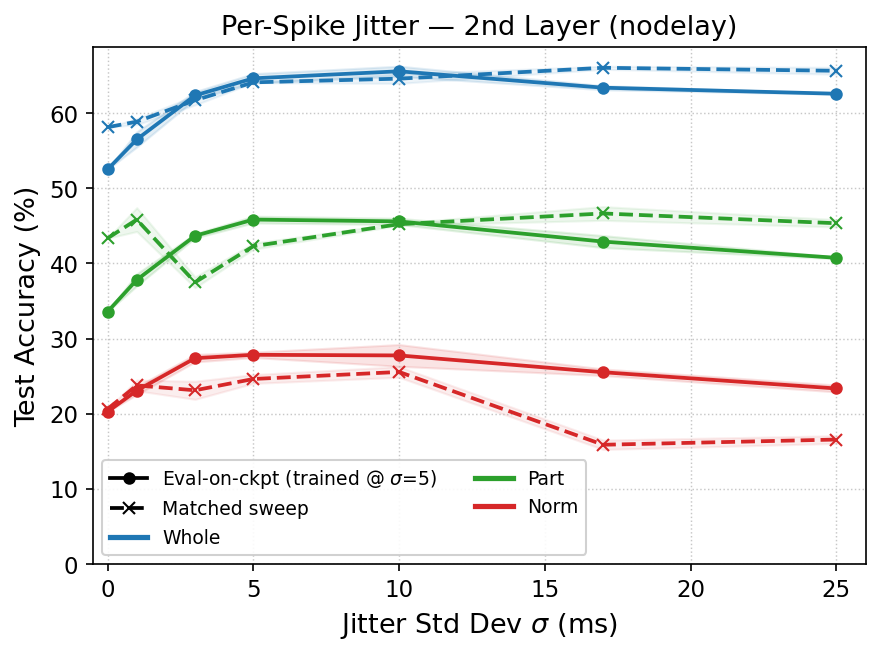

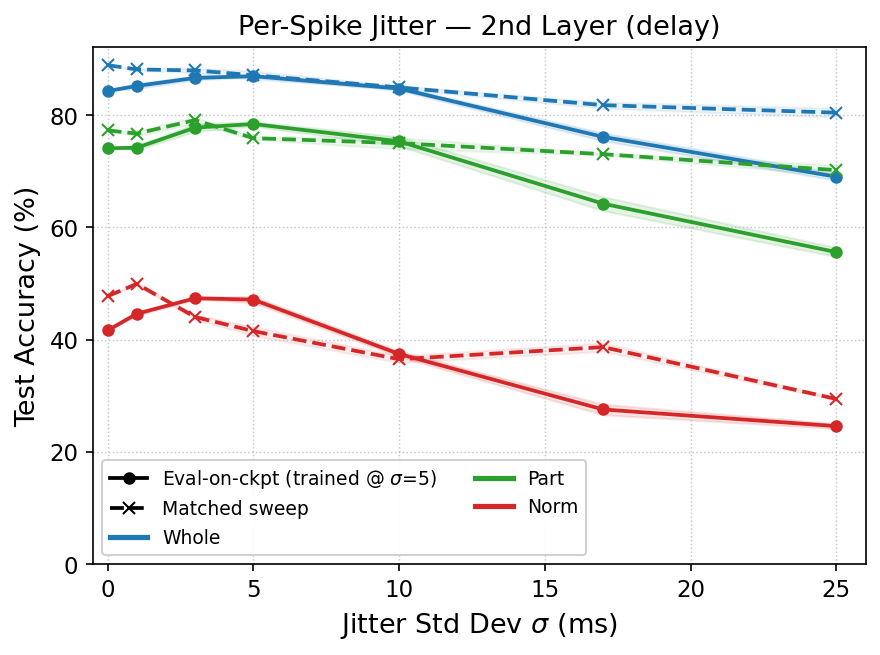

In [18]:
for delay_tag in ("nodelay", "delay"):
    token = f"sigma{CHECKPOINT_SIGMA_JITTER}"
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"jitter_2ndLayer_{ds}_{delay_tag}_evalon_{token}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("jitter/log")
        / f"jitter_2ndLayer_{ds}_{delay_tag}_jitter_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    plot_comparison(
        new_paths, old_paths, int,
        xlabel=r"Jitter Std Dev $\sigma$ (ms)",
        title=f"Per-Spike Jitter — 2nd Layer ({delay_tag})",
        xlim=(-0.5, 26),
        checkpoint_label=rf"trained @ $\sigma$={CHECKPOINT_SIGMA_JITTER}",
    )

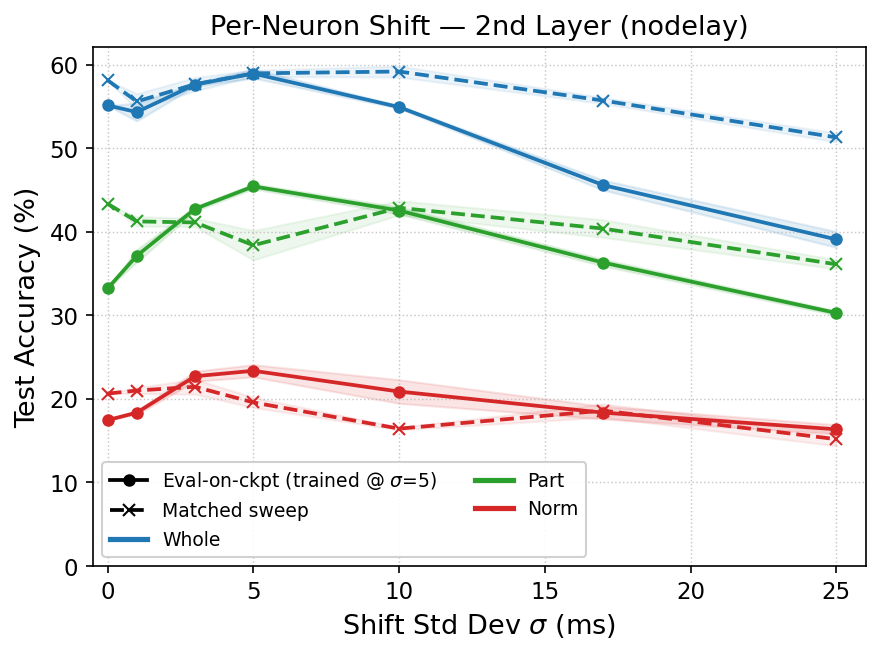

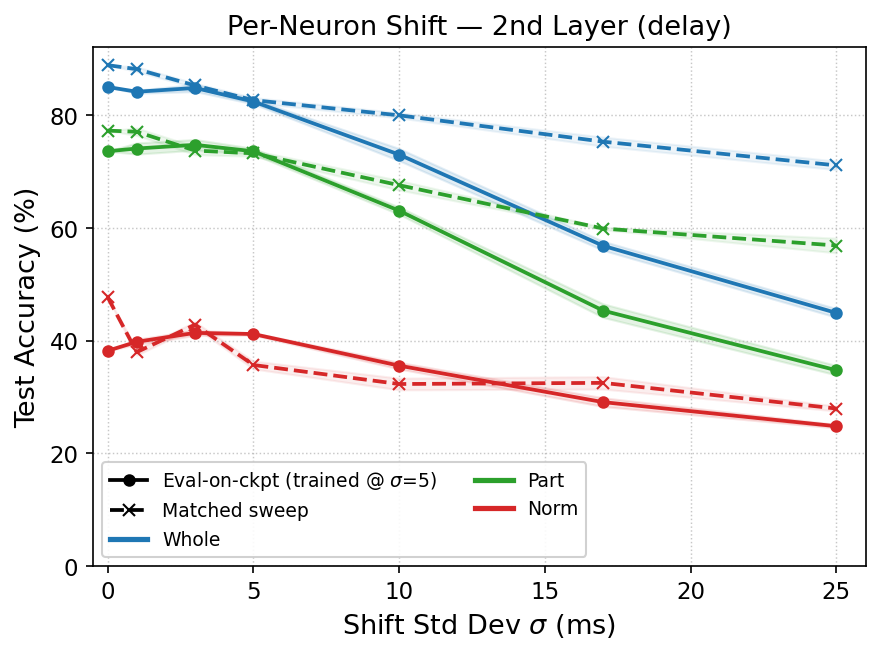

In [19]:
for delay_tag in ("nodelay", "delay"):
    token = f"sigma{CHECKPOINT_SIGMA_SHIFT}"
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"shift_2ndLayer_{ds}_{delay_tag}_evalon_{token}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("shift/log")
        / f"shift_2ndLayer_{ds}_{delay_tag}_shift_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    plot_comparison(
        new_paths, old_paths, int,
        xlabel=r"Shift Std Dev $\sigma$ (ms)",
        title=f"Per-Neuron Shift — 2nd Layer ({delay_tag})",
        xlim=(-0.5, 26),
        checkpoint_label=rf"trained @ $\sigma$={CHECKPOINT_SIGMA_SHIFT}",
    )

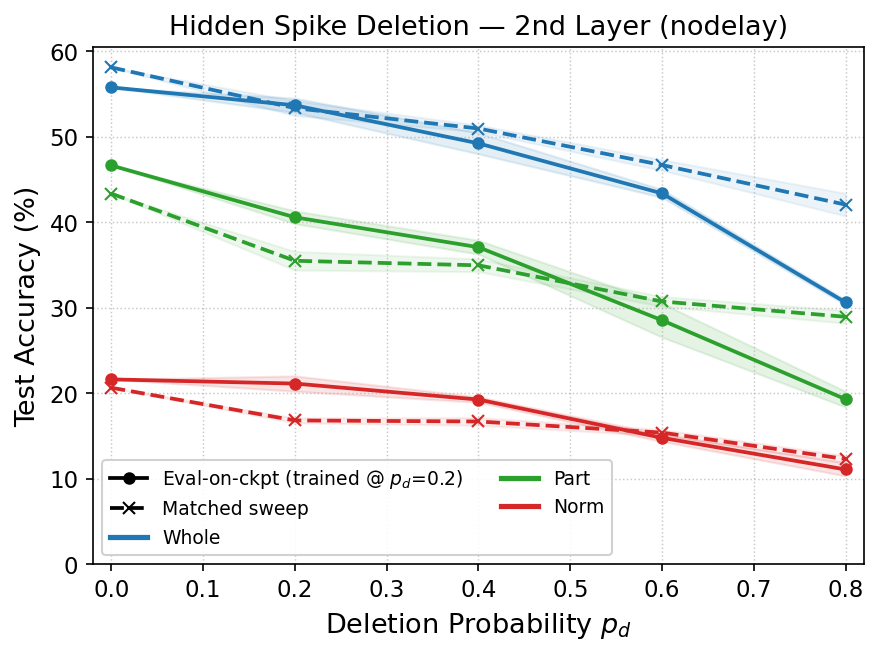

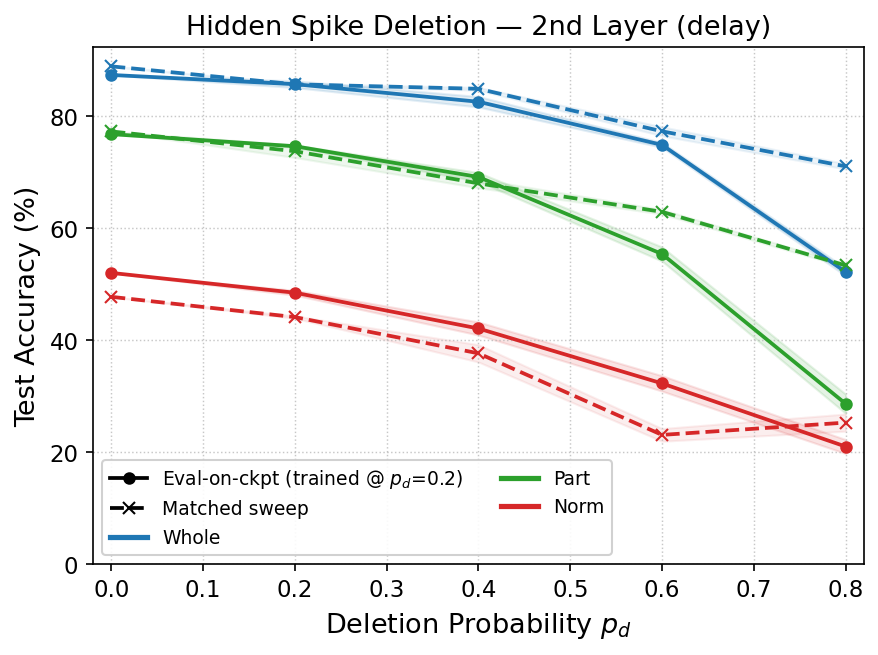

In [20]:
_pd_token_plot = f"pd{int(round(CHECKPOINT_PD_DELETION * 10)):02d}"
for delay_tag in ("nodelay", "delay"):
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"deletion_2ndLayer_{ds}_{delay_tag}_evalon_{_pd_token_plot}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("deletion/log")
        / f"deletion_2ndLayer_{ds}_{delay_tag}_deletion_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    plot_comparison(
        new_paths, old_paths, float,
        xlabel=r"Deletion Probability $p_d$",
        title=f"Hidden Spike Deletion — 2nd Layer ({delay_tag})",
        xlim=(-0.02, 0.82),
        checkpoint_label=rf"trained @ $p_d$={CHECKPOINT_PD_DELETION}",
    )